In [147]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [148]:
df = pd.read_csv("Data/tech_job_market_2019_2026 (1).csv")

In [149]:
df.head()

,job_id,company_name,company_type,sector,company_size_employees,hq_country,job_role,seniority_level,years_experience_min,years_experience_max,...,application_deadline,date_position_filled,position_status,number_of_applicants,number_of_interview_rounds,offers_extended,offers_accepted,salary_min_usd,salary_max_usd,layoff_within_12_months_flag
0,JOB041385,CobaltWealth,MNC,HealthTech,146085,Germany,SOC Analyst,Mid,3,5,...,11/12/2023 0:00,11/20/2023,Filled,98.0,4.0,5.0,5.0,-1,-1,N
1,JOB018462,DriftLearn,Mid-size,Cloud/Infra,5882,USA,Mobile Engineer (iOS),Mid,1,4,...,6/29/2025 0:00,NaN,Open,134.0,2.0,1.0,0.0,NaN,NaN,No
2,JOB110011,AnchorBuzz Labs,MNC,HealthTech,186507,USA,QA Engineer,Lead,7,15,...,1/24/2026 0:00,2/8/2026,Filled,36.0,4.0,1.0,1.0,238800,274700,0
3,JOB073462,KiteSphere,Unicorn,HealthTech,10930,Brazil,Research Scientist,Entry,1,4,...,12/9/2020 0:00,12/21/2020,Filled,300.0,1.0,6.0,5.0,96300,104000,Yes
4,JOB051683,AetherNode Co,MNC,Social/AdTech,42510,USA,Product Manager,Senior,6,9,...,7/19/2025 0:00,9/15/2025,Filled,43.0,3.0,1.0,1.0,"$186,800",245400,1


In [150]:
df.shape

(115000, 28)

### There are 115000 rows and 28 columns


In [151]:

df.info()

<class 'pandas.DataFrame'>
RangeIndex: 115000 entries, 0 to 114999
Data columns (total 28 columns):
 #   Column                        Non-Null Count   Dtype  
---  ------                        --------------   -----  
 0   job_id                        115000 non-null  str    
 1   company_name                  115000 non-null  str    
 2   company_type                  115000 non-null  str    
 3   sector                        115000 non-null  str    
 4   company_size_employees        115000 non-null  int64  
 5   hq_country                    115000 non-null  str    
 6   job_role                      115000 non-null  str    
 7   seniority_level               115000 non-null  str    
 8   years_experience_min          115000 non-null  int64  
 9   years_experience_max          115000 non-null  int64  
 10  required_tech_stack           115000 non-null  str    
 11  primary_programming_language  92525 non-null   str    
 12  work_mode                     115000 non-null  str    


### There are 21 string type cols, 3 integer type cols, 4 float type cols


In [152]:
df.describe()

,company_size_employees,years_experience_min,years_experience_max,number_of_applicants,number_of_interview_rounds,offers_extended,offers_accepted
count,115000.000000,115000.000000,115000.000000,113890.000000,114564.000000,114670.000000,114670.000000
mean,105386.103122,3.004452,6.665443,181.659215,3.307653,1.349786,1.196634
std,102117.290040,3.093383,5.073654,436.344753,1.418283,1.457267,1.122837
min,10.000000,0.000000,0.000000,-5.000000,1.000000,0.000000,0.000000
25%,6038.750000,1.000000,3.000000,62.000000,2.000000,1.000000,1.000000
50%,88364.000000,2.000000,6.000000,119.000000,3.000000,1.000000,1.000000
75%,169840.250000,5.000000,9.000000,213.000000,4.000000,1.000000,1.000000
max,488674.000000,24.000000,24.000000,36816.000000,8.000000,8.000000,10.000000


In [153]:
df.isnull().sum()

job_id                              0
company_name                        0
company_type                        0
sector                              0
company_size_employees              0
hq_country                          0
job_role                            0
seniority_level                     0
years_experience_min                0
years_experience_max                0
required_tech_stack                 0
primary_programming_language    22475
work_mode                           0
visa_sponsorship_offered            0
job_location_country                0
job_location_city               25107
salary_currency                     0
posting_date                        0
application_deadline             5757
date_position_filled            25781
position_status                     0
number_of_applicants             1110
number_of_interview_rounds        436
offers_extended                   330
offers_accepted                   330
salary_min_usd                   3318
salary_max_u

In [154]:
df.isnull().sum().sum()

np.int64(87962)

### There are 87962 missing values in 10 cols and there are 3 cols which have missing values greater than 20000 so we will analys if we need to drop them

In [155]:
df.duplicated().sum()

np.int64(1193)

### The dataset contain 1193 exact duplicates so we need to drop them.

In [156]:
df = df.drop_duplicates()


In [157]:
df.duplicated().sum()

np.int64(0)

In [158]:
df.shape

(113807, 28)

### Now we have 113807 rows and 28 cols left

In [159]:
df.describe()

,company_size_employees,years_experience_min,years_experience_max,number_of_applicants,number_of_interview_rounds,offers_extended,offers_accepted
count,113807.000000,113807.000000,113807.000000,112704.000000,113373.000000,113479.000000,113479.000000
mean,105407.621552,3.004174,6.664124,181.779112,3.307525,1.349298,1.196415
std,102128.678701,3.092817,5.072197,437.798085,1.418054,1.456431,1.122430
min,10.000000,0.000000,0.000000,-5.000000,1.000000,0.000000,0.000000
25%,6044.500000,1.000000,3.000000,62.000000,2.000000,1.000000,1.000000
50%,88378.000000,2.000000,6.000000,119.000000,3.000000,1.000000,1.000000
75%,169835.500000,5.000000,9.000000,213.000000,4.000000,1.000000,1.000000
max,488674.000000,24.000000,24.000000,36816.000000,8.000000,8.000000,10.000000


All the cols except (number_of_interview_rounds) col has approx same mean and std or std>mean .<br>
So, we can conclude from here that the distribution of data is very uncertain. so we need to check skewness of each column.<br>
Minimum number_of_applicants here is -5 which is invalid data.<br>
Some cols also has mean greater than median which also indicates a strong possibility of right skewness/outliers.<br>
Max is very high than 75% in each col which indicates strong outliers possibilities.<br>
There are missing values in 4 numerical cols.<br>

In [160]:
df.select_dtypes(include="string").columns


Index(['job_id', 'company_name', 'company_type', 'sector', 'hq_country',
       'job_role', 'seniority_level', 'required_tech_stack',
       'primary_programming_language', 'work_mode', 'visa_sponsorship_offered',
       'job_location_country', 'job_location_city', 'salary_currency',
       'posting_date', 'application_deadline', 'date_position_filled',
       'position_status', 'salary_min_usd', 'salary_max_usd',
       'layoff_within_12_months_flag'],
      dtype='str')

In [162]:
df["company_name"].value_counts().sample(10)

company_name
aethernode co                    2
ZephyrWealth Technologies        2
grovesocial                      1
HelixCare Systems              105
  AetherNode Co                 10
latticeledger inc                1
HELIXFIN INC                     5
VertexCompute Inc             1620
LumenArcade Technologies        10
BeaconCampus                   265
Name: count, dtype: int64

In [163]:
df["company_type"].value_counts()

company_type
MNC           55501
Mid-size      20079
Unicorn       15921
FAANG-tier    15783
Startup        6523
Name: count, dtype: int64

In [164]:
df["sector"].value_counts().sample(10)

sector
fintech            139
saas                88
EdTech           11414
Social/AdTech     8938
ai/ml               87
social/adtech       99
Fintech          13008
edtech             125
logistics           49
Cloud/Infra       6502
Name: count, dtype: int64

Sector-<br>
The sector column contains inconsistent capitalization for some categories.<br>
For Example, E-commerce/e-commerce, HealthTech/healthtech, and AI/ML/ai/ml represents the same categories but are stored as seperate values.<br>


In [165]:
df["sector"]=df["sector"].str.strip().str.lower()

In [166]:
df["sector"].value_counts()


sector
e-commerce       16663
healthtech       15270
fintech          13147
edtech           11539
social/adtech     9037
ai/ml             8890
saas              8610
crypto/web3       8041
cloud/infra       6562
cybersecurity     5726
logistics         5280
gaming            5042
Name: count, dtype: int64

In [167]:
df["hq_country"].value_counts()

hq_country
USA            35356
India          18763
UK             15411
Germany         7108
Canada          6179
Brazil          5890
Singapore       5765
France          5050
Australia       3423
UAE             3158
Israel          3012
Netherlands     2613
Ireland         2079
Name: count, dtype: int64

In [168]:
df["job_role"].value_counts().sample(10)

job_role
machine learning engineer       23
MOBILE ENGINEER (ANDROID)       31
Machine Learning Engineer       17
Data Analyst                  3061
mobile engineer (ios)           41
CLOUD ENGINEER                  14
Data Engineer                 2870
RESEARCH SCIENTIST              13
Data Scientist                  15
Frontend Engineer             5786
Name: count, dtype: int64

Job_role<br>
The job_role col contains inconsistent capitalization for some categories.<br>
For Example, Frontend Engineer/FRONTEND ENGINEER represents the same categories but are stored as seperate values.<br


In [169]:
df["job_role"]=df["job_role"].str.strip().str.lower()

In [170]:
df["job_role"].value_counts()

job_role
backend engineer                 6095
embedded systems engineer        6069
qa engineer                      6005
software engineer                5960
frontend engineer                5950
mobile engineer (ios)            5901
mobile engineer (android)        5855
full stack engineer              5847
devops engineer                  3676
infrastructure engineer          3642
cloud engineer                   3607
platform engineer                3593
site reliability engineer        3590
machine learning engineer        3172
data analyst                     3137
analytics engineer               2993
data scientist                   2987
research scientist               2963
data engineer                    2945
product owner                    2912
product manager                  2910
associate product manager        2878
technical program manager        2874
soc analyst                      2325
security engineer                2311
penetration tester               2310
app

In [171]:
df["seniority_level"].value_counts()

seniority_level
Mid          38686
Entry        28322
Senior       22776
Lead         10366
Intern        9157
Principal     4500
Name: count, dtype: int64

In [172]:
df["required_tech_stack"].value_counts()

required_tech_stack
Sketch, Framer                                             274
Adobe XD, Framer                                           252
Figma, Framer                                              251
Adobe XD, Figma                                            248
Figma, Adobe XD                                            247
Sketch, Adobe XD                                           243
Framer, Sketch                                             237
Framer, Figma                                              233
Sketch, Figma                                              229
Figma, Sketch                                              225
Adobe XD, Sketch                                           223
Framer, Adobe XD                                           201
C++, React                                                 189
TypeScript, Swift                                          188
C++, TypeScript                                            187
C++, Go                            

 It has some values which shows same tech stack but with different order so we need to first arrange these values in same order.

In [173]:
df['required_tech_stack'] = df['required_tech_stack'].apply(
    lambda x: ', '.join(sorted(map(str.strip, x.split(','))))
    if isinstance(x, str) else x
)

In [174]:
df["required_tech_stack"].value_counts()

required_tech_stack
Adobe XD, Figma, Framer, Sketch                            2867
Amplitude, Figma, Jira, Notion, SQL                        2754
Adobe XD, Figma, Sketch                                     739
Adobe XD, Framer, Sketch                                    716
Adobe XD, Figma, Framer                                     706
Figma, Framer, Sketch                                       699
Amplitude, Figma, Notion, SQL                               597
Amplitude, Figma, Jira, SQL                                 573
Figma, Jira, Notion, SQL                                    573
Amplitude, Jira, Notion, SQL                                558
Amplitude, Figma, Jira, Notion                              549
Framer, Sketch                                              511
Adobe XD, Figma                                             495
Figma, Framer                                               484
Adobe XD, Sketch                                            466
Figma, Sketch       

In [175]:
df["primary_programming_language"].value_counts()

primary_programming_language
Python        19209
Go            14503
Bash           5904
Java           5864
JavaScript     5810
Kotlin         5739
C++            5730
TypeScript     5718
Swift          5716
Scala          4449
R              4431
SQL            4386
C              3007
Unknown         548
TBD             530
Name: count, dtype: int64

In [176]:
df["work_mode"].value_counts()

work_mode
Hybrid            48423
Remote            31986
Onsite            26470
HYBRID             1487
hybrid             1333
remote              593
Work From Home      560
WFH                 556
REMOTE              548
ONSITE              472
onsite              463
In-office           461
On-site             455
Name: count, dtype: int64

work_mode<br>
The work_mode column contains inconsistent capitalization for some categories.<br>
For Example, HYBRID/hybrid represents the same categories but are stored as seperate values.<br>


In [177]:
df["work_mode"] = df["work_mode"].str.strip().str.lower()

In [178]:
df["work_mode"] = df["work_mode"].replace({
    "wfh": "remote",
    "work from home": "remote",
    "remote": "remote",
    
    "on-site": "onsite",
    "in-office": "onsite",
    "onsite": "onsite",
    
    "hybrid": "hybrid"
})

In [179]:
df["work_mode"].value_counts()

work_mode
hybrid    51243
remote    34243
onsite    28321
Name: count, dtype: int64

In [180]:
df["visa_sponsorship_offered"].value_counts()



visa_sponsorship_offered
0        19625
FALSE    19555
N        19553
No       19346
Yes       9001
TRUE      8937
1         8897
Y         8893
Name: count, dtype: int64

visa_sponsorship_offered<br>
The visa_sponsorship_offered col contains inconsistent capitalization for some categories.<br>
For Example, 0/N/No/FALSE represents the same categories but are stored as seperate values.<br


df["visa_sponsorship_offered"].value_counts()


In [305]:
df["visa_sponsorship_offered"] = df["visa_sponsorship_offered"].replace({
    "0": "No",
    "FALSE": "No",
    "N": "No",
    "No": "No",
    
    "Yes": "Yes",
    "TRUE": "Yes",
    "1": "Yes",
    "Y": "Yes"
})


In [182]:
df["visa_sponsorship_offered"].value_counts()

visa_sponsorship_offered
No     78079
Yes    35728
Name: count, dtype: int64

In [183]:
df["job_location_country"].value_counts()


job_location_country
USA            35895
India          19426
UK             14477
Germany         7098
Canada          6240
Singapore       5718
Brazil          5304
France          4764
Australia       3549
Israel          3268
UAE             3029
Netherlands     2912
Ireland         2127
Name: count, dtype: int64

In [184]:
df["job_location_city"].value_counts(ascending=False)

job_location_city
Singapore         4469
Austin            4057
New York          4047
Denver            4010
San Francisco     3984
Seattle           3975
Chicago           3972
Boston            3918
London            2840
Manchester        2821
Cambridge         2816
Edinburgh         2813
Hyderabad         2205
Chennai           2196
Noida             2192
Bangalore         2186
Pune              2184
Gurugram          2158
Mumbai            2110
Sao Paulo         2082
Rio de Janeiro    2059
Lyon              1877
Paris             1861
Dublin            1660
Frankfurt         1414
Munich            1406
Hamburg           1390
Sydney            1378
Herzliya          1353
Melbourne         1339
Berlin            1336
Tel Aviv          1221
Toronto           1216
Montreal          1215
Abu Dhabi         1202
Vancouver         1194
Waterloo          1192
Dubai             1159
Amsterdam         1155
Eindhoven         1153
Not Specified      145
Name: count, dtype: int64

Here is one value called Not Specified so we will convert it into NaN value

In [185]:
df["job_location_city"] = df["job_location_city"].replace("Not Specified", np.nan)

In [186]:
df["job_location_city"].isna().sum()

np.int64(24992)

In [187]:
df["job_location_city"].value_counts(dropna=False).head(10)

job_location_city
NaN              24992
Singapore         4469
Austin            4057
New York          4047
Denver            4010
San Francisco     3984
Seattle           3975
Chicago           3972
Boston            3918
London            2840
Name: count, dtype: int64

In [188]:
df["salary_currency"].value_counts()


salary_currency
USD    35895
INR    19426
EUR    16901
GBP    14477
CAD     6240
SGD     5718
BRL     5304
AUD     3549
ILS     3268
AED     3029
Name: count, dtype: int64

In [189]:
df["position_status"].value_counts()


position_status
Filled       90118
Open         10051
Cancelled     7970
Withdrawn     5668
Name: count, dtype: int64

In [190]:
df["layoff_within_12_months_flag"].value_counts()

layoff_within_12_months_flag
N        24905
0        24736
FALSE    24717
No       24526
Y         3785
Yes       3759
1         3734
TRUE      3645
Name: count, dtype: int64


layoff_within_12_months_flag<br>
The layoff_within_12_months_flag col contains inconsistent capitalization for some categories.<br>
For Example, 0/N/No/FALSE represents the same categories but are stored as seperate values.<br





In [306]:
df["layoff_within_12_months_flag"] = df["layoff_within_12_months_flag"].replace({
    "0": "No",
    "FALSE": "No",
    "N": "No",
    "No": "No",
    
    "Yes": "Yes",
    "TRUE": "Yes",
    "1": "Yes",
    "Y": "Yes"
})

In [192]:
df["layoff_within_12_months_flag"].value_counts()

layoff_within_12_months_flag
No     98884
Yes    14923
Name: count, dtype: int64

In [193]:
df["number_of_applicants"].value_counts().sample(10)

number_of_applicants
8990.0      1
452.0      34
574.0      17
1278.0      1
1828.0      1
12.0      310
114.0     443
628.0      10
555.0       9
1263.0      1
Name: count, dtype: int64

In [194]:
df.loc[df["number_of_applicants"] < 0,"number_of_applicants"] = np.nan

In [195]:
df["number_of_applicants"].value_counts()

number_of_applicants
53.0       612
52.0       604
45.0       597
57.0       596
47.0       594
49.0       589
36.0       588
62.0       580
65.0       580
68.0       579
63.0       578
33.0       577
56.0       573
70.0       573
67.0       571
42.0       571
55.0       568
66.0       564
60.0       563
72.0       563
48.0       561
61.0       561
31.0       561
44.0       559
75.0       558
81.0       558
59.0       557
78.0       555
77.0       552
71.0       552
34.0       552
74.0       549
51.0       547
69.0       545
37.0       544
50.0       544
43.0       540
80.0       540
46.0       539
94.0       538
84.0       536
38.0       536
89.0       530
32.0       529
58.0       528
41.0       528
92.0       528
35.0       527
82.0       527
29.0       526
79.0       526
40.0       524
64.0       524
87.0       523
26.0       521
73.0       521
83.0       517
76.0       515
28.0       514
25.0       513
96.0       511
27.0       509
39.0       507
86.0       506
93.0       506
22.0

In [196]:
df["application_deadline"].value_counts()

application_deadline
Open Until Filled    2799
Rolling              2781
4/2/2026 0:00          80
3/24/2026 0:00         79
3/15/2026 0:00         76
3/23/2026 0:00         75
4/7/2026 0:00          75
2/19/2026 0:00         74
4/18/2024 0:00         73
3/17/2025 0:00         73
5/11/2026 0:00         73
3/2/2026 0:00          73
2/16/2026 0:00         73
2/25/2026 0:00         73
11/1/2025 0:00         73
3/5/2025 0:00          73
3/18/2025 0:00         73
3/10/2026 0:00         72
3/25/2026 0:00         72
3/10/2024 0:00         72
3/26/2025 0:00         72
4/10/2025 0:00         71
3/8/2026 0:00          71
3/6/2026 0:00          71
3/6/2024 0:00          70
4/2/2025 0:00          70
3/3/2025 0:00          70
3/9/2026 0:00          70
4/22/2025 0:00         69
6/4/2026 0:00          69
3/1/2024 0:00          69
3/11/2026 0:00         69
3/14/2026 0:00         69
4/11/2026 0:00         69
3/22/2025 0:00         69
3/6/2025 0:00          69
3/17/2024 0:00         68
3/3/2026 0:00    

Refrential and Logical Analysis

In [307]:
(df["years_experience_max"] < df["years_experience_min"]).sum()

np.int64(0)

In [269]:
mask = df['years_experience_min'] > df['years_experience_max']

df.loc[mask, ['years_experience_min', 'years_experience_max']] = np.nan

In [267]:
print(mask.sum())

0


In [201]:
(df["years_experience_min"] < 0).sum()

np.int64(0)

In [202]:
(df["years_experience_max"] < 0).sum()

np.int64(0)

In [203]:
(df["offers_accepted"] > df["offers_extended"]).sum()

np.int64(591)

In [263]:
mask = df['offers_accepted'] > df['offers_extended']

df.loc[mask, ['offers_accepted', 'offers_extended']] = np.nan

In [264]:
print(mask.sum())

0


In [206]:
(df["offers_extended"] > df["number_of_applicants"]).sum()

np.int64(126)

In [270]:
mask = df['offers_extended'] > df['number_of_applicants']

df.loc[mask, ['offers_extended', 'number_of_applicants']] = np.nan

In [271]:
print(mask.sum())

0


In [209]:
(df["offers_accepted"] < 0).sum()

np.int64(0)

In [210]:
(df["offers_extended"] < 0).sum()

np.int64(0)

In [211]:
(df["number_of_applicants"] < 0).sum()

np.int64(0)

In [212]:
(df["number_of_interview_rounds"] > df["number_of_applicants"]).sum()

np.int64(96)

In [272]:
mask = df['number_of_interview_rounds'] > df['number_of_applicants']

df.loc[mask, ['number_of_interview_rounds', 'number_of_applicants']] = np.nan

In [273]:
print(mask.sum())

0


In [215]:
(df["number_of_interview_rounds"] < 0).sum()

np.int64(0)

In [216]:
date_cols = [
    "posting_date",
    "date_position_filled"
]

In [217]:
for col in date_cols:
    df[col] = pd.to_datetime(df[col], errors="coerce")

In [218]:
df[date_cols].dtypes

posting_date            datetime64[us]
date_position_filled    datetime64[us]
dtype: object

In [219]:
(df["date_position_filled"] < df["posting_date"]).sum()

np.int64(439)

In [274]:
mask = df['posting_date'] > df['date_position_filled']

df.loc[mask, ['posting_date', 'date_position_filled']] = np.nan

In [275]:
print(mask.sum())

0


In [222]:
df[(df["position_status"] == "Filled") & (df["date_position_filled"].isna())].shape[0]

2264

In [223]:
df[(df["position_status"] == "Open") & (df["date_position_filled"].notna())].shape[0]

0

In [224]:
df["salary_min_usd"] = pd.to_numeric(
    df["salary_min_usd"]
    .str.replace("$", "", regex=False)
    .str.replace(",", "", regex=False)
    .str.replace("USD", "", regex=False)
    .str.strip(),
    errors="coerce"
)



In [225]:


df["salary_max_usd"] = pd.to_numeric(
    df["salary_max_usd"]
    .str.replace("$", "", regex=False)
    .str.replace(",", "", regex=False)
    .str.replace("USD", "", regex=False)
    .str.strip(),
    errors="coerce"
)

In [226]:
(df["salary_max_usd"] < df["salary_min_usd"]).sum()

np.int64(445)

In [276]:
mask = df['salary_min_usd'] > df['salary_max_usd']

df.loc[mask, ['salary_min_usd', 'salary_max_usd']] = np.nan

In [277]:
print(mask.sum())

0


In [229]:
(df["salary_min_usd"] < 0).sum()

np.int64(727)

In [230]:
(df["salary_max_usd"] < 0).sum()

np.int64(727)

In [231]:
df.loc[df["salary_min_usd"] < 0, "salary_min_usd"] = np.nan

In [232]:
df.loc[df["salary_max_usd"] < 0, "salary_max_usd"] = np.nan

### Conclusion <br>

There are 315 rows where min experience is greater than max experience.<br>
In 597 rows there is offer accepted greater than offer extended.<br>
In 370 rows there is offer extended greater than number of applicants.<br>
In 247 rows there is number of applicants less than 0.<br>
In 466 rows there is no.. of interview rounds greater than no. of applicants.<br>
In 445 rows there is posting date greater than the date when the positions were filled.<br>
There are 1845 rows where the position status is showing filled but there no value for the date when the position was filled.<br>
452 rows have min salary greater than max salary.<br>
737 rows have min and max salary in negative.
  

In [233]:
df.isnull().sum()

job_id                              0
company_name                        0
company_type                        0
sector                              0
company_size_employees              0
hq_country                          0
job_role                            0
seniority_level                     0
years_experience_min              315
years_experience_max              315
required_tech_stack                 0
primary_programming_language    22263
work_mode                           0
visa_sponsorship_offered            0
job_location_country                0
job_location_city               24992
salary_currency                     0
posting_date                      439
application_deadline             5695
date_position_filled            25953
position_status                     0
number_of_applicants             1568
number_of_interview_rounds        530
offers_extended                  1045
offers_accepted                   919
salary_min_usd                   5134
salary_max_u

# HANDLING MISSING VALUES

In [234]:
# job_location_city
df["job_location_city"] = df["job_location_city"].fillna("unknown")

In [235]:
# primary_programming_language
df["primary_programming_language"] = df["primary_programming_language"].fillna("not known")

In [236]:
# number_of_applicants
df["number_of_applicants"] = df["number_of_applicants"].fillna(df["number_of_applicants"].median())

In [237]:
# number_of_interview_rounds 
df["number_of_interview_rounds"] = df["number_of_interview_rounds"].fillna(df["number_of_interview_rounds"].median())

In [238]:
# offers_extended
df["offers_extended"] = df["offers_extended"].fillna(df["offers_extended"].median())

In [239]:
# offers_accepted
df["offers_accepted"] = df["offers_accepted"].fillna(df["offers_accepted"].median())


In [240]:
# salary_min_usd
df["salary_min_usd"] = df["salary_min_usd"].fillna(df["salary_min_usd"].median())

In [241]:
# salary_max_usd
df["salary_max_usd"] = df["salary_max_usd"].fillna(df["salary_max_usd"].median())

In [242]:
df.isnull().sum()

job_id                              0
company_name                        0
company_type                        0
sector                              0
company_size_employees              0
hq_country                          0
job_role                            0
seniority_level                     0
years_experience_min              315
years_experience_max              315
required_tech_stack                 0
primary_programming_language        0
work_mode                           0
visa_sponsorship_offered            0
job_location_country                0
job_location_city                   0
salary_currency                     0
posting_date                      439
application_deadline             5695
date_position_filled            25953
position_status                     0
number_of_applicants                0
number_of_interview_rounds          0
offers_extended                     0
offers_accepted                     0
salary_min_usd                      0
salary_max_u

### FEATURE ENGINEERING

In [243]:
# deadline_date

df["deadline_date"] = pd.to_datetime(df["application_deadline"], errors="coerce")

In [244]:
df['application_deadline'] =(df['application_deadline'].astype("string").str.strip().str.lower())

Here we have done (Feature Engineering) and make a seperate col "deadline_date" which only contains datetime dtype values and not string values like "open until filled" and "rolling" for further manipulation of nan values of "date_position_filled" col

In [245]:
# hiring _period

df["hiring_period"]= (df["date_position_filled"] - df["posting_date"]).dt.days

Shows how many days a company will take to fill a position

In [246]:
# experience range

df["experience range"] = (df["years_experience_max"] - df["years_experience_min"])

Shows the flexibility in the required experience level

In [247]:
# salary_range

df["salary_range"] = (df["salary_max_usd"] - df["salary_min_usd"])

Shows the flexibility in salary offered

## OUTLIER DETECTION

In [248]:
num_cols = df.select_dtypes(include= "number").columns
print(num_cols)

Index(['company_size_employees', 'years_experience_min',
       'years_experience_max', 'number_of_applicants',
       'number_of_interview_rounds', 'offers_extended', 'offers_accepted',
       'salary_min_usd', 'salary_max_usd', 'hiring_period', 'experience range',
       'salary_range'],
      dtype='str')


In [249]:
num_cols = df.select_dtypes(include="number").columns

df[num_cols].skew().sort_values(ascending=False)

number_of_applicants          32.783026
salary_range                  28.197584
salary_max_usd                 9.359543
offers_accepted                3.223113
offers_extended                3.171319
years_experience_max           1.312202
years_experience_min           1.250949
hiring_period                  1.125857
salary_min_usd                 1.002417
experience range               0.940308
company_size_employees         0.743284
number_of_interview_rounds     0.402412
dtype: float64


 Six numerical features show significant positive skewness, with number_of_applicants being extremely positively skewed (32.62), followed by salary_range (28.06), salary_max_usd (9.33), offers_accepted (3.19), and offers_extended (3.15). This indicates the presence of extreme values/outliers 

OUTLIER DETECTION using IQR method

In [250]:
Q1 = df[num_cols].quantile(0.25)
Q3 = df[num_cols].quantile(0.75)

IQR = Q3 - Q1

lower = Q1 - 1.5 * IQR
upper = Q3 + 1.5 * IQR

outlier_count = ((df[num_cols] < lower) | (df[num_cols] > upper)).sum()

print(outlier_count)

company_size_employees           59
years_experience_min           2939
years_experience_max           4480
number_of_applicants           6881
number_of_interview_rounds      232
offers_extended               21786
offers_accepted               23663
salary_min_usd                 3372
salary_max_usd                 3600
hiring_period                  2119
experience range               3342
salary_range                   4657
dtype: int64


In [308]:
most_outliers_cols = [
    "number_of_applicants",
    "salary_range",
    "salary_max_usd",
    "offers_accepted",
    "offers_extended",
    "years_experience_max",
    "years_experience_min",
    "hiring_period",
    "salary_min_usd",
    "company_size_employees",
    "number_of_interview_rounds",
    "experience range"
]

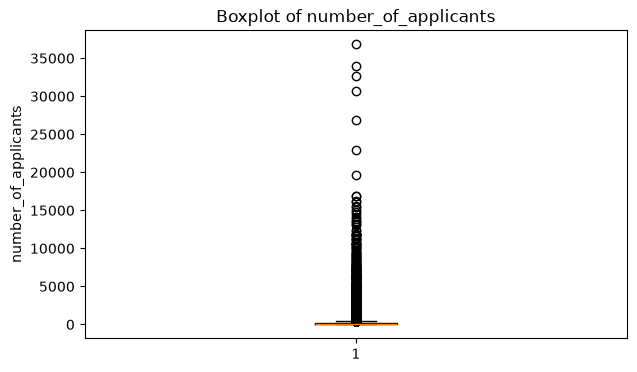

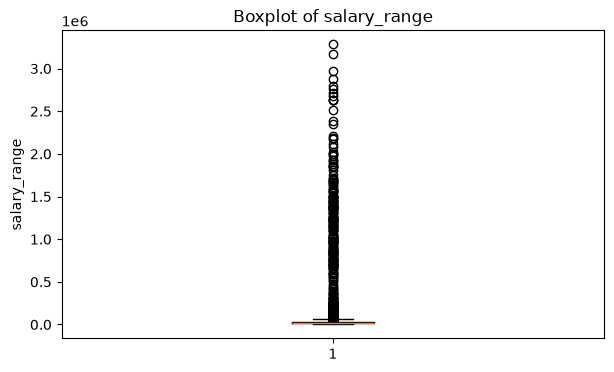

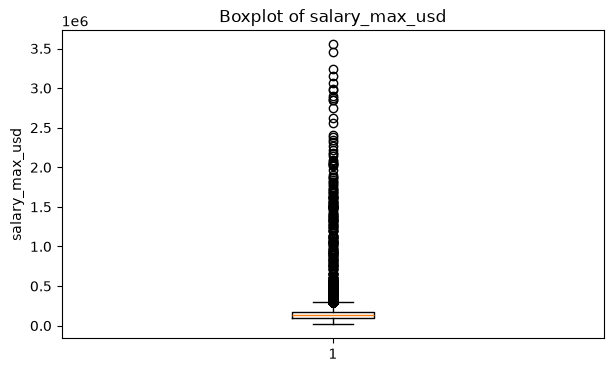

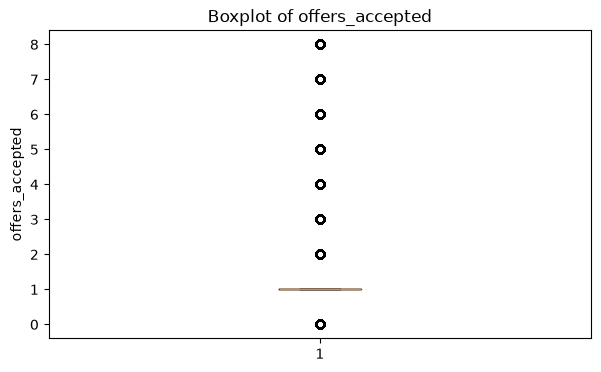

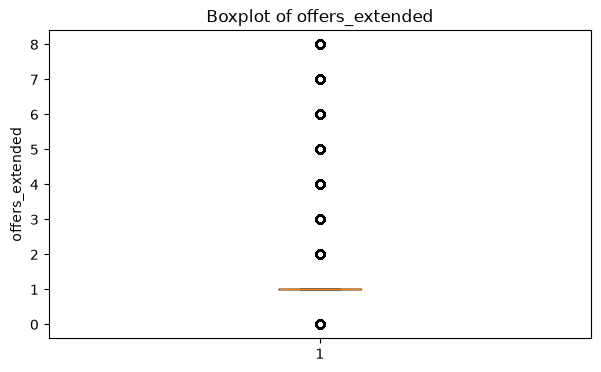

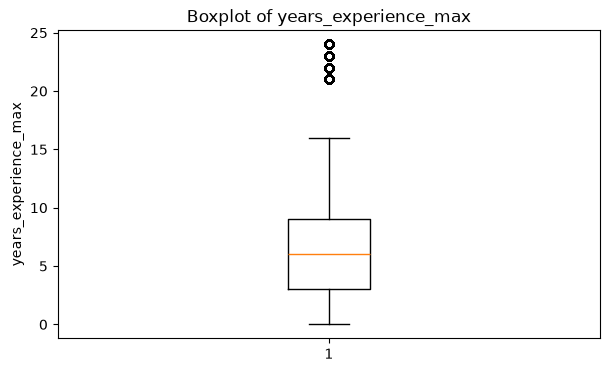

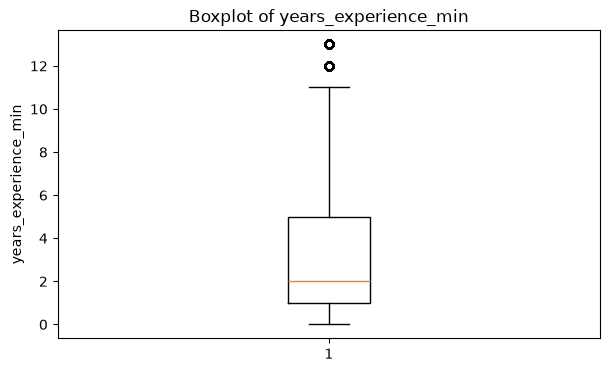

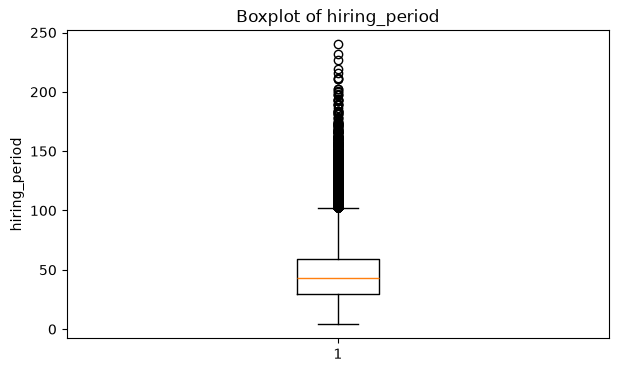

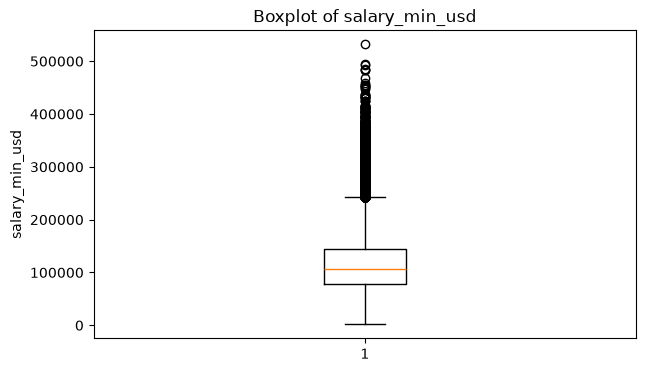

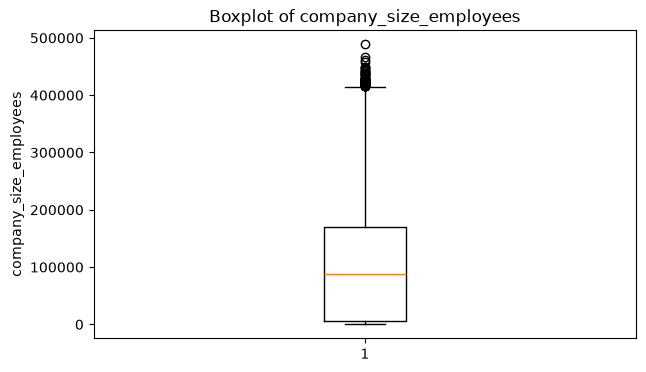

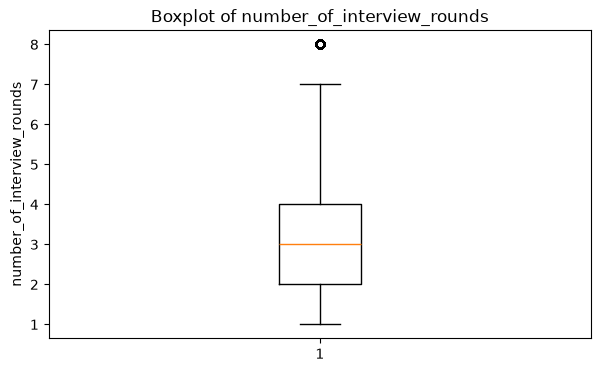

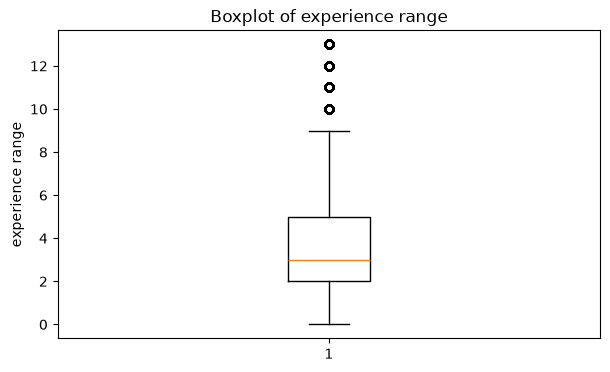

In [252]:


for col in most_outliers_cols:
    data = pd.to_numeric(df[col], errors="coerce").dropna()

    plt.figure(figsize=(7, 4))
    plt.boxplot(data)
    plt.title(f"Boxplot of {col}")
    plt.ylabel(col)
    plt.show()

"Several numerical variables contain extreme values and show right-skewed distributions. These observations were retained because they may represent genuine variations in the tech job market rather than data errors."

## UNIVARIATE ANALYSIS

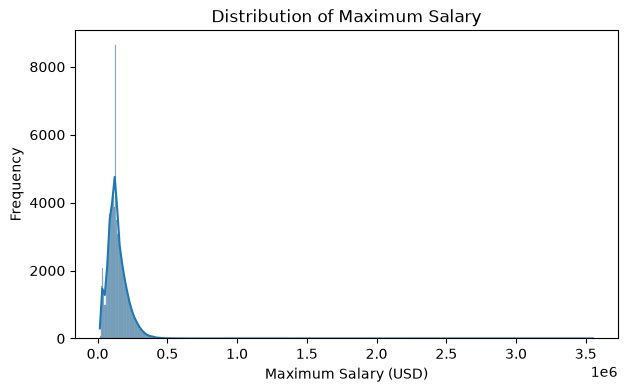

In [280]:
plt.figure(figsize=(7,4))

sns.histplot(df['salary_max_usd'].dropna(), kde=True)

plt.title('Distribution of Maximum Salary')
plt.xlabel('Maximum Salary (USD)')
plt.ylabel('Frequency')

plt.show()

Most jobs offer relatively lower maximum salaries.<br>

The distribution is strongly right-skewed, with a few very high salary values.

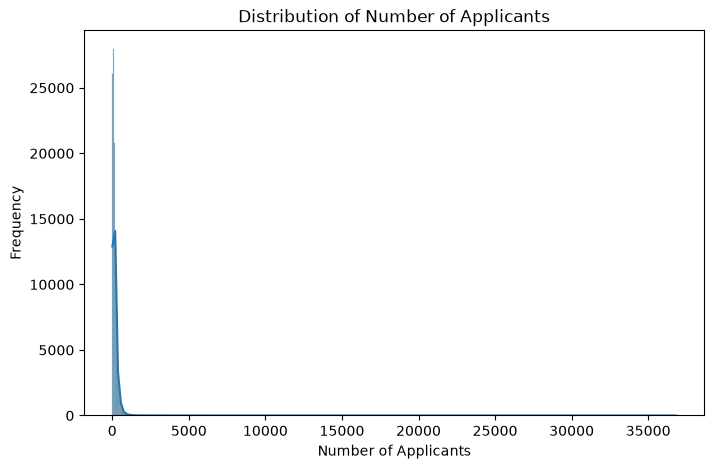

In [281]:
plt.figure(figsize=(8,5))

sns.histplot(df['number_of_applicants'].dropna(), kde=True)

plt.title('Distribution of Number of Applicants')
plt.xlabel('Number of Applicants')
plt.ylabel('Frequency')

plt.show()

Most jobs receive a relatively small number of applicants.

A few jobs have extremely high applicant counts, creating a right-skewed distribution.

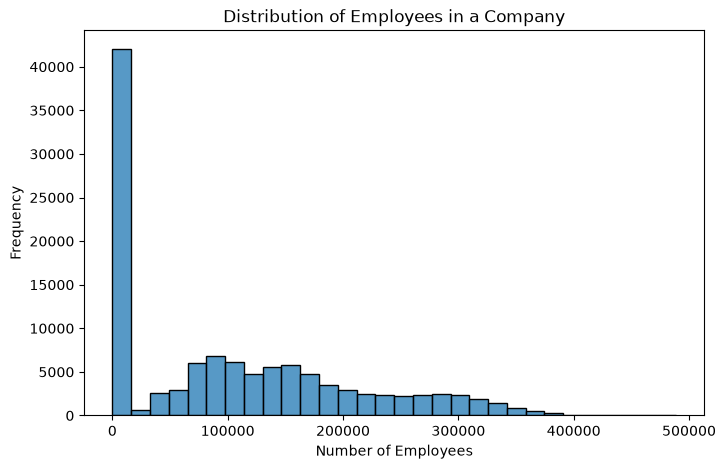

In [293]:
plt.figure(figsize=(8,5))

sns.histplot(df['company_size_employees'].dropna(), bins=30)

plt.title('Distribution of Employees in a Company')
plt.xlabel('Number of Employees')
plt.ylabel('Frequency')

plt.show()

Most companies have relatively fewer employees.

Large companies with hundreds of thousands of employees are present but less common.

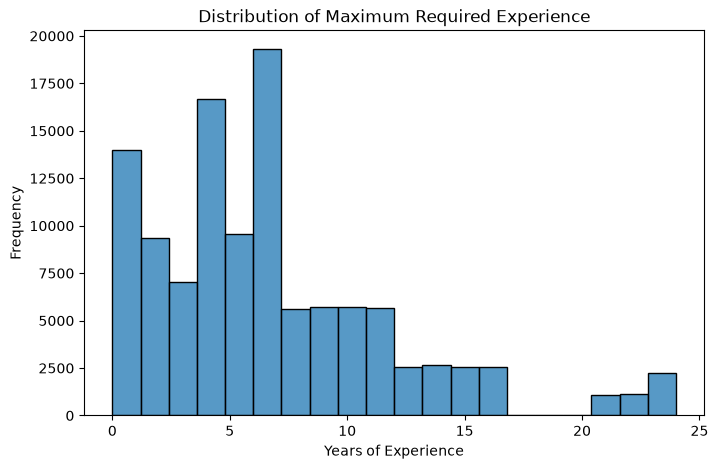

In [283]:
plt.figure(figsize=(8,5))

sns.histplot(df['years_experience_max'].dropna(), bins=20)

plt.title('Distribution of Maximum Required Experience')
plt.xlabel('Years of Experience')
plt.ylabel('Frequency')

plt.show()

Most jobs require approximately 1–10 years of experience.

Very high experience requirements are relatively rare.

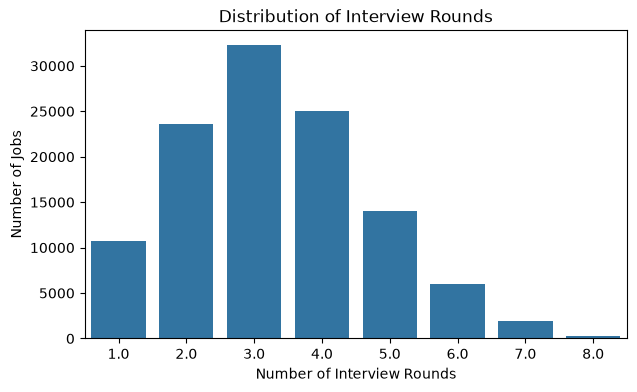

In [284]:
plt.figure(figsize=(7,4))

sns.countplot(x=df['number_of_interview_rounds'])

plt.title('Distribution of Interview Rounds')
plt.xlabel('Number of Interview Rounds')
plt.ylabel('Number of Jobs')

plt.show()

3 interview rounds are the most common.

Most jobs have around 2–5 rounds, while 7–8 rounds are uncommon

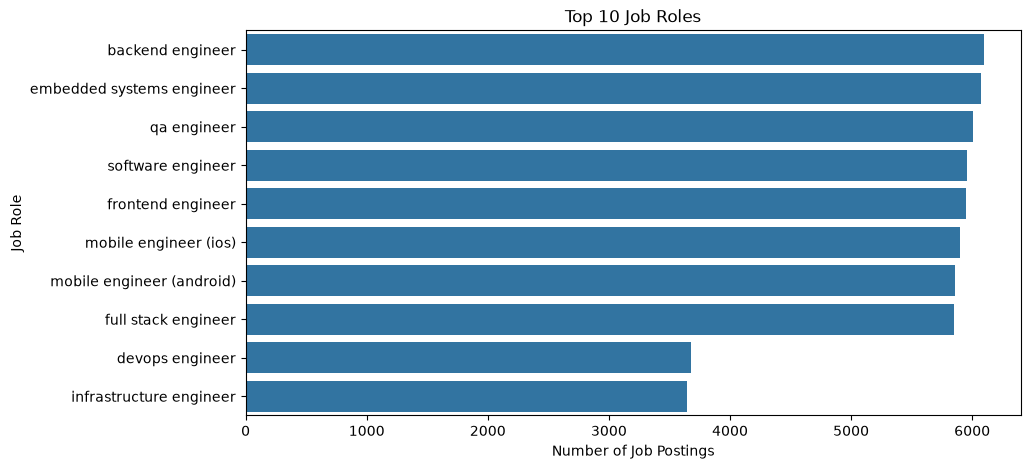

In [285]:
top_roles = df['job_role'].value_counts().head(10)

plt.figure(figsize=(10,5))

sns.barplot(x=top_roles.values, y=top_roles.index)

plt.title('Top 10 Job Roles')
plt.xlabel('Number of Job Postings')
plt.ylabel('Job Role')

plt.show()

Backend Engineer and Embedded Systems Engineer are among the most frequently posted roles.

Engineering roles dominate the top job postings.

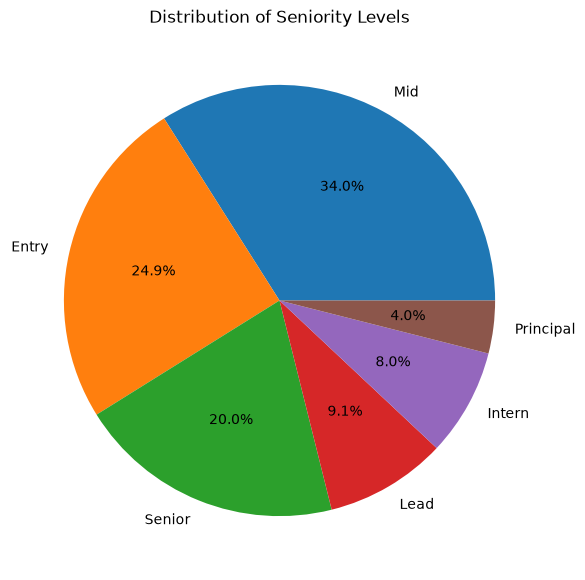

In [292]:
seniority_counts = df['seniority_level'].value_counts()

plt.figure(figsize=(7,7))

plt.pie(
    seniority_counts.values,
    labels=seniority_counts.index,
    autopct='%1.1f%%'
)

plt.title('Distribution of Seniority Levels')

plt.show()

Mid-level positions have the highest share.

Entry and senior positions also represent significant portions, while Principal roles are relatively few.

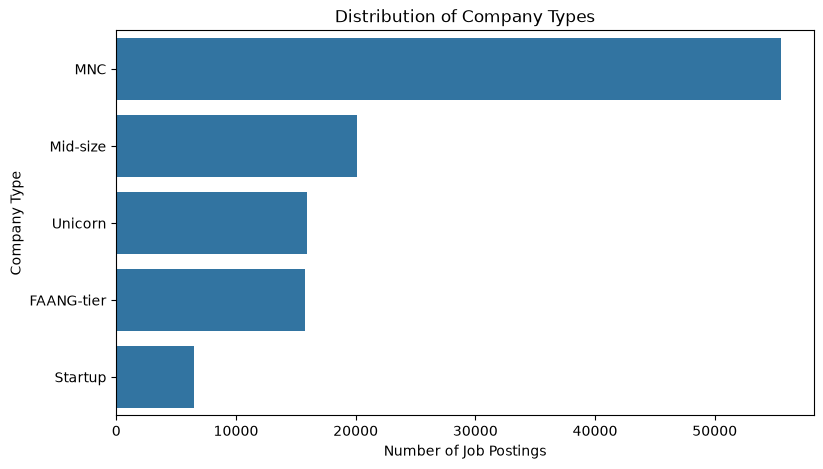

In [287]:
company_counts = df['company_type'].value_counts()

plt.figure(figsize=(9,5))

sns.barplot(
    x=company_counts.values,
    y=company_counts.index
)

plt.title('Distribution of Company Types')
plt.xlabel('Number of Job Postings')
plt.ylabel('Company Type')

plt.show()

MNCs account for the largest number of job postings.

Startup, mid-size, and other company types contribute smaller shares.

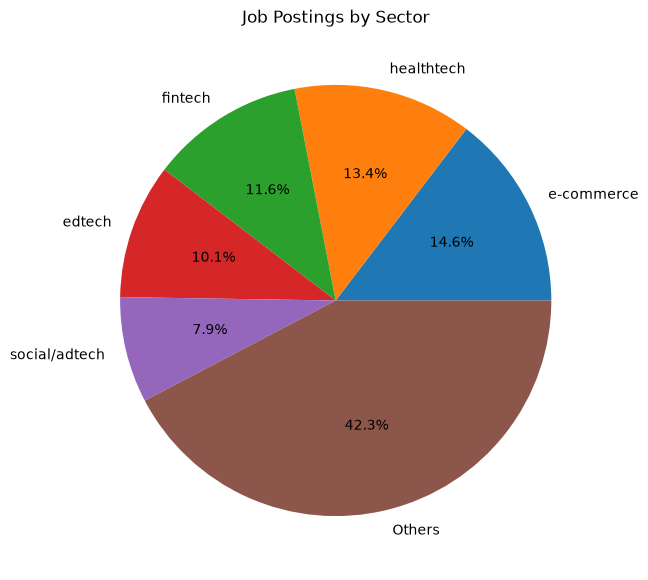

In [295]:
sector_counts = df['sector'].value_counts()

top5 = sector_counts.head(5)
others = sector_counts.iloc[5:].sum()

pie_data = pd.concat([
    top5,
    pd.Series({'Others': others})
])

plt.figure(figsize=(7,7))

plt.pie(
    pie_data.values,
    labels=pie_data.index,
    autopct='%1.1f%%',
)

plt.title('Job Postings by Sector')

plt.show()

Others is the largest sector category.

E-commerce and healthtech also have notable shares, while social/edtech is comparatively smaller.

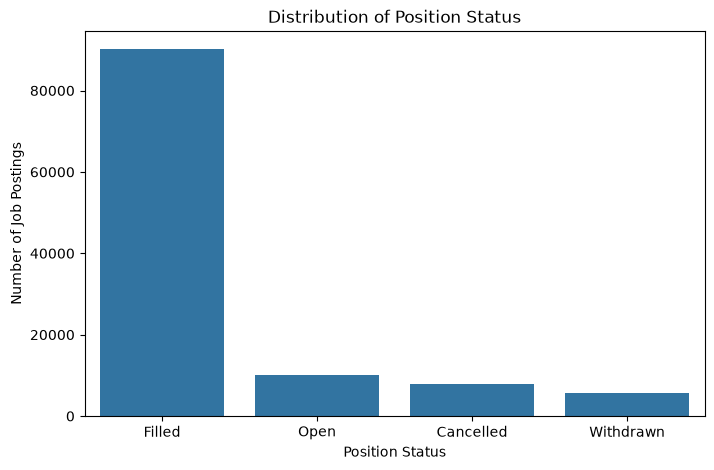

In [ ]:
plt.figure(figsize=(8,5))

sns.countplot(
    x=df['position_status'],
    order=df['position_status'].value_counts().index
)

plt.title('Distribution of Position Status')
plt.xlabel('Position Status')
plt.ylabel('Number of Job Postings')

plt.show()

Open positions dominate, showing most jobs are still available.

Filled, cancelled, and withdrawn positions are comparatively fewer.

## SUMMARY OF UNIVARIATE ANALYSIS

Most jobs offer relatively lower maximum salaries, with a few high-paying roles creating a right-skewed distribution.<br>
Applicant counts are generally low, but a few jobs attract exceptionally high numbers of applicants.<br>
Most companies have relatively fewer employees, while very large companies are less common.<br>
Job experience requirements are mainly concentrated between 1–10 years.<br>
Most jobs have around 2–5 interview rounds, with 3 rounds being the most common.<br>
Backend Engineer and Embedded Systems Engineer are among the most frequently posted roles, showing the dominance of engineering jobs.<br>
Mid-level positions have the highest share, followed by entry and senior-level roles.<br>
MNCs contribute the largest share of job postings, while “Others,” e-commerce, and healthtech are notable sectors.<br>
Most positions are still open, whereas filled, cancelled, and withdrawn jobs make up a smaller proportion.

## HEATMAP for standing correlation

<Axes: >

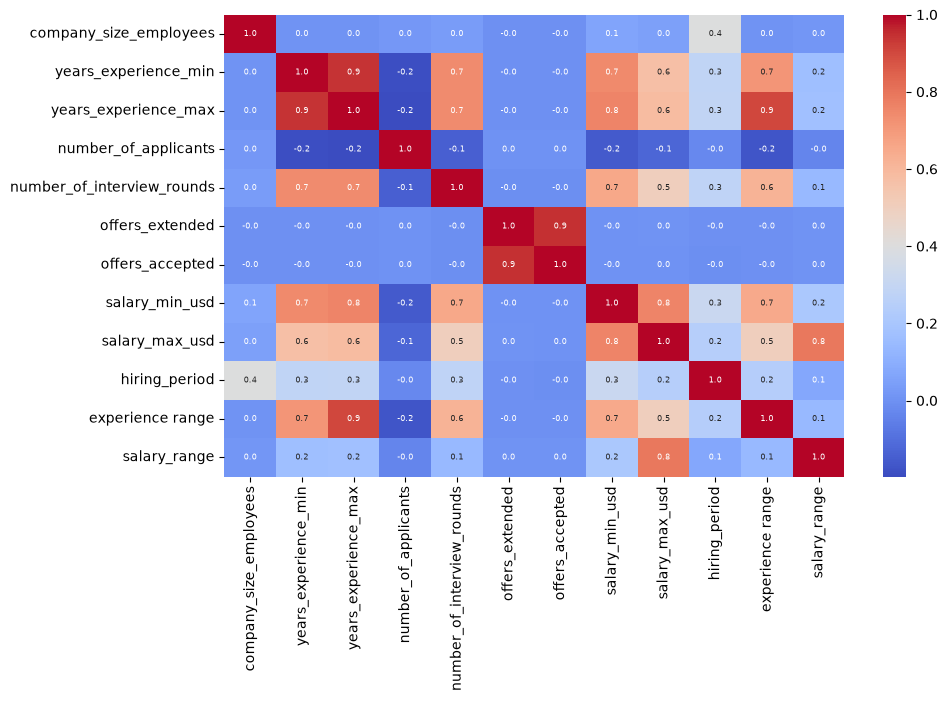

In [311]:
plt.figure(figsize=(10,6))
sns.heatmap(df.corr(numeric_only = True) , annot = True , fmt = '.1f' , cmap = 'coolwarm' , annot_kws = {'size':6})

### By analyzing the heatmap we select the following column for Bivariate analysis

years_experience_min ↔ salary_min_usd<br>
salary_min_usd ↔ salary_max_usd<br>
years_experience_max ↔ number_of_interview_rounds<br>
offers_extended ↔ offers_accepted<br>
years_experience_min ↔ number_of_interview_rounds

## BIVARIATE ANALYSIS

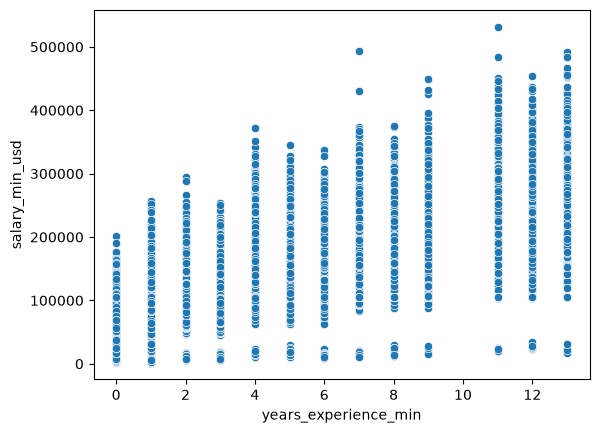

In [299]:
sns.scatterplot(data=df, x='years_experience_min', y='salary_min_usd')
plt.show()

Minimum salary generally increases with higher experience requirements.

Higher-experience roles show a wider salary range and some high-salary outliers.

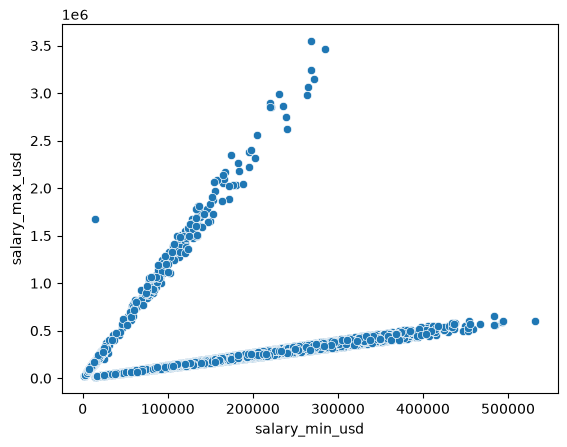

In [301]:
sns.scatterplot(data=df, x='salary_min_usd', y='salary_max_usd')
plt.show()

There is a strong positive relationship between minimum and maximum salary.

Jobs with higher minimum salaries generally have higher maximum salaries as well.

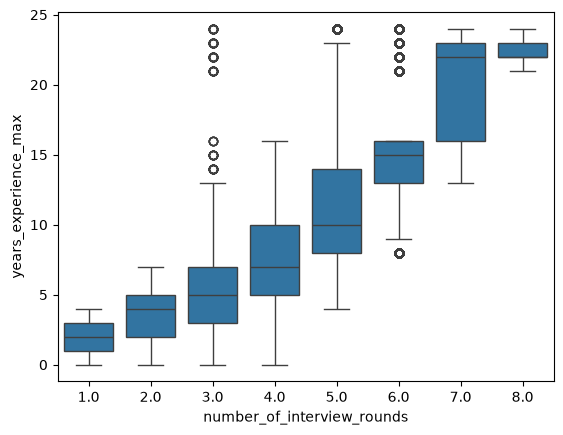

In [302]:
sns.boxplot(data=df, x='number_of_interview_rounds', y='years_experience_max')
plt.show()

The required maximum experience tends to increase as interview rounds increase.

Higher-round jobs show greater experience requirements and some outliers.

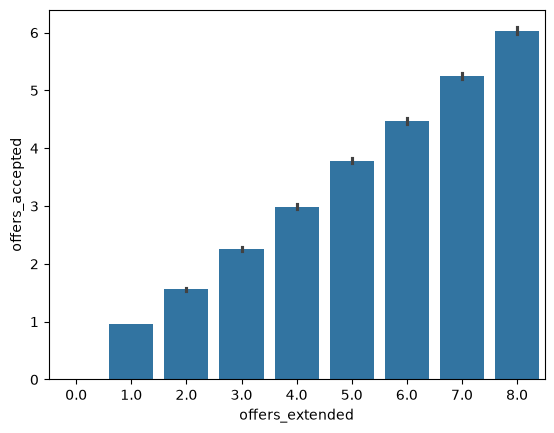

In [303]:
sns.barplot(data=df, x='offers_extended', y='offers_accepted')
plt.show()

Offers accepted increase consistently as offers extended increase.

This indicates a strong positive relationship between extended and accepted offers.

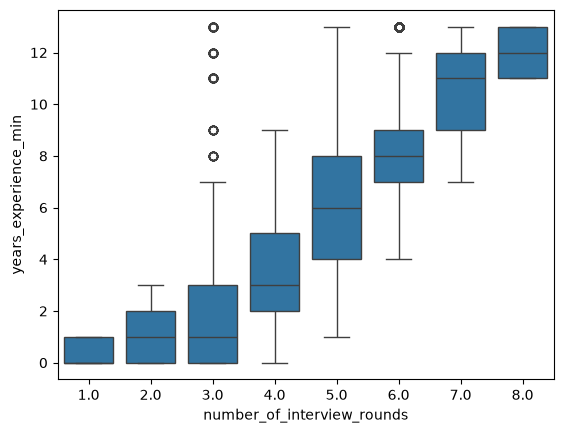

In [304]:
sns.boxplot(data=df, x='number_of_interview_rounds', y='years_experience_min')
plt.show()

Minimum experience requirements generally rise with more interview rounds.

Jobs with 6–8 interview rounds typically require higher minimum experience.

## SUMMARY OF BIVARIATE ANALYSIS

Experience requirements and salary levels show a strong positive relationship.<br>
Higher minimum salaries are generally associated with higher maximum salaries.<br>
More interview rounds tend to be associated with higher experience requirements.<br>
Offers accepted increase consistently as offers extended increase.<br>
Overall, experience, salary, and interview rounds are positively related to the hiring process.